# Photon flux computation

Computes photon fluxes at user defined distances

In [29]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

%matplotlib widget

## Define Constants

In [15]:
import numpy as np

# Constants
R_sun = 6.957e8          # m
T_sun = 5800             # K
sigma = 5.670367e-8      # Stefan-Boltzmann constant (W m^-2 K^-4)
L_sun = 4 * np.pi * R_sun**2 * sigma * T_sun**4   # ~3.83e26 W

AU = 1.496e11            # m
R_earth = 6.371e6        # m
h = 6.62607015e-34       # Planck's constant (J s)
c = 2.99792458e8         # m/s
pc_to_m = 3.08568e16     # parsec to meters
kB = 1.380649e-23


# User inputs
D_pc = 30.0
D = D_pc * pc_to_m       # distance to system (m)
albedo = 0.3             # geometric albedo
wl = 550e-9              # wavelength (m) - change for different bands (e.g. 7e-6 for mid-IR)

# 1. Incident stellar flux at planet (W/m²)
F_incident = L_sun / (4 * np.pi * AU**2)
print(f"Stellar flux at planet: {F_incident:.1f} W/m²")

# ---------------- REFLECTED LIGHT ----------------
# Approximate planet/star contrast (visible/near-IR)
contrast_reflected = (albedo / 4.0) * (R_earth / AU)**2
print(f"Planet/Star contrast (reflected): {contrast_reflected:.2e}")

# Stellar flux at Earth
F_star_earth = L_sun / (4 * np.pi * D**2)

# Reflected planet flux at Earth (W/m²)
F_planet_reflected = F_star_earth * contrast_reflected
print(f"Reflected planet flux at Earth: {F_planet_reflected:.2e} W/m²")

# Photon flux (photons / m² / s) at single wavelength approximation
E_photon = h * c / wl
photon_flux_reflected = F_planet_reflected / E_photon
print(f"Reflected photon flux (~{wl*1e9:.0f} nm): {photon_flux_reflected:.4f} photons m⁻² s⁻¹\n")

# ---------------- THERMAL EMISSION (simple blackbody approx) ----------------
T_planet = 255.0         # Effective temperature (K) for Earth-like
epsilon = 1.0            # Emissivity

# Total thermal power emitted by planet
P_thermal = epsilon * 4 * np.pi * R_earth**2 * sigma * T_planet**4

# Thermal flux at Earth (isotropic approximation)
F_planet_thermal = P_thermal / (4 * np.pi * D**2)

print(f"Thermal planet flux at Earth (total): {F_planet_thermal:.2e} W/m²")

# Photon flux at chosen wavelength (monochromatic approx - crude)
photon_flux_thermal = F_planet_thermal / E_photon
print(f"Thermal photon flux approx (~{wl*1e9:.0f} nm): {photon_flux_thermal:.4f} photons m⁻² s⁻¹")

Stellar flux at planet: 1387.7 W/m²
Planet/Star contrast (reflected): 1.36e-10
Reflected planet flux at Earth: 4.93e-21 W/m²
Reflected photon flux (~550 nm): 0.0136 photons m⁻² s⁻¹

Thermal planet flux at Earth (total): 1.14e-20 W/m²
Thermal photon flux approx (~550 nm): 0.0314 photons m⁻² s⁻¹


In [22]:

# Better to use known solar constant for accuracy rather than full integral for reflected
def compute_photon_flux(distance):
    # Use analytical approximation (most reliable for reflected)
    solar_constant = 1366.0  # W/m² at 1 AU
    contrast = (albedo / 4.0) * (R_earth / AU)**2
    
    F_star_at_earth = 3.826e26 / (4 * np.pi * distance**2)   # L_sun / 4pi D^2
    F_planet = F_star_at_earth * contrast
    
    E_avg = h * c / 550e-9
    photon_flux = F_planet / E_avg
    return photon_flux

# print("Photon flux (photons m⁻² s⁻¹):", compute_photon_flux())

In [21]:
T_planet = 255.0      # Effective temperature (K)
epsilon = 0.95        # Emissivity (close to 1 for rocky planets)

# Total thermal power emitted by the planet
P_thermal = epsilon * 4 * np.pi * R_earth**2 * sigma * T_planet**4

# Flux at Earth (isotropic approximation)
F_thermal_earth = P_thermal / (4 * np.pi * D**2)
print(f"Thermal energy flux at Earth: {F_thermal_earth:.2e} W/m²")

# Photon flux at a representative mid-IR wavelength (e.g. 10 μm)
wl_thermal = 10e-6
E_photon_thermal = h * c / wl_thermal
photon_flux_thermal = F_thermal_earth / E_photon_thermal
print(f"Thermal photon flux (~10 μm): {photon_flux_thermal:.5f} photons m⁻² s⁻¹")

Thermal energy flux at Earth: 1.08e-20 W/m²
Thermal photon flux (~10 μm): 0.54311 photons m⁻² s⁻¹


In [24]:
D_pc = np.logspace(0, 3, 200)          # 1 to 1000 pc
D_m = D_pc * 3.08568e16
sgl_amplification = 1.17e11

fluxes = []
for d in D_m:
    flux = compute_photon_flux(d)
    flux *= sgl_amplification
    fluxes.append(flux)



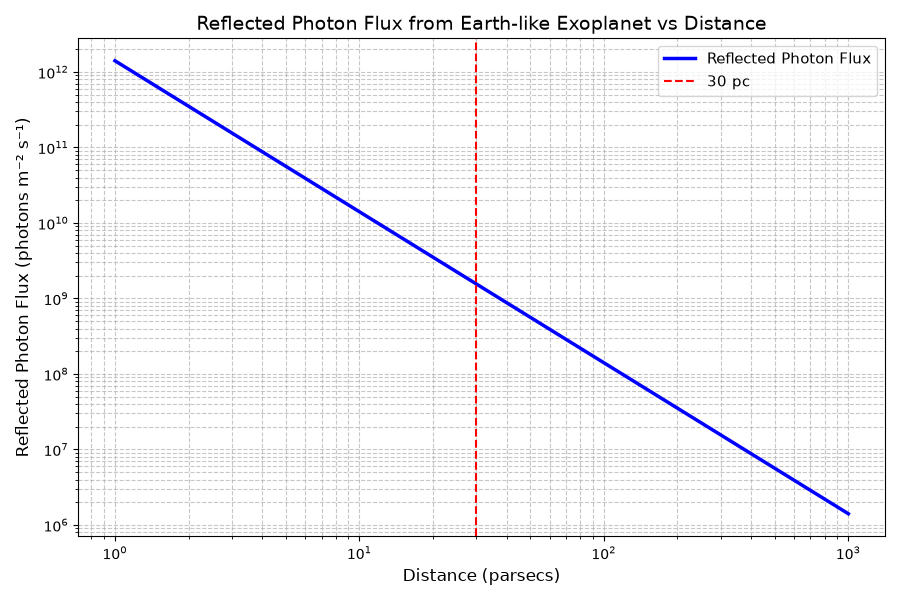

In [30]:
# Plot
plt.figure(figsize=(9, 6))
plt.loglog(D_pc, fluxes, 'b-', linewidth=2.5, label='Reflected Photon Flux')

plt.xlabel('Distance (parsecs)', fontsize=12)
plt.ylabel('Reflected Photon Flux (photons m⁻² s⁻¹)', fontsize=12)
plt.title('Reflected Photon Flux from Earth-like Exoplanet vs Distance', fontsize=14)

plt.grid(True, which='both', ls='--', alpha=0.7)
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='30 pc')
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('reflected_photon_flux_vs_distance.png', dpi=250, bbox_inches='tight')
plt.show()

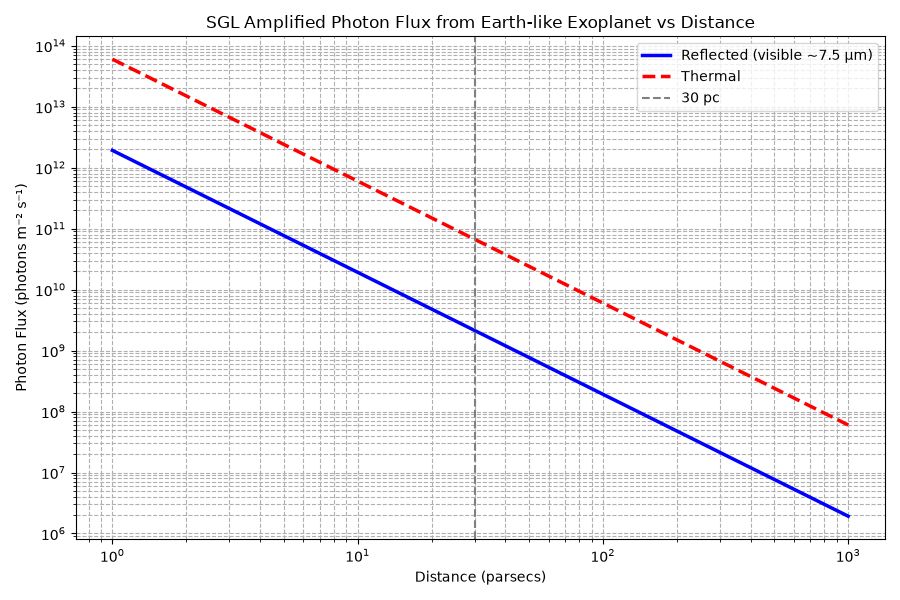

In [37]:
# Reflected (visible)
contrast = (albedo / 4) * (R_earth / AU)**2
F_star_earth = L_sun / (4 * np.pi * D_m**2)
F_planet_ref = F_star_earth * contrast
E_vis = h * c / 750e-9
photon_ref = F_planet_ref / E_vis

# Thermal (mid-IR)
P_thermal = 4 * np.pi * R_earth**2 * sigma * T_planet**4
F_thermal = P_thermal / (4 * np.pi * D_m**2)
E_ir = h * c / 10e-6
photon_thermal = F_thermal / E_ir

# Plot
plt.figure(figsize=(9, 6))
plt.loglog(D_pc, photon_ref*sgl_amplification, "b-", lw=2.5, label="Reflected (visible ~7.5 µm)")
plt.loglog(D_pc, photon_thermal*sgl_amplification, "r--", lw=2.5, label="Thermal ")

plt.xlabel("Distance (parsecs)")
plt.ylabel("Photon Flux (photons m⁻² s⁻¹)")
plt.title("SGL Amplified Photon Flux from Earth-like Exoplanet vs Distance")
plt.grid(True, which="both", ls="--")
plt.axvline(30, color="gray", linestyle="--", label="30 pc")
plt.legend()
plt.tight_layout()
plt.savefig("photon_flux_reflected_thermal.png", dpi=250)
plt.show()